<a href="https://colab.research.google.com/github/Sara-Mishra-2024/Phishing-classifier/blob/main/Phishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn xgboost imbalanced-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df1 = pd.read_csv("dataset_phishing.csv")
df2 = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")
print(df1.head())
print(df2.head())


                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0                0                

In [ ]:
df1['Label'] = df1['status'].map({'phishing': 1, 'legitimate': 0})
df2['Label'] = df2['label']

In [ ]:
df1 = df1.rename(columns={
    'url': 'URL'
})
df2 = df2.rename(columns={
    'URL': 'URL'
})


In [ ]:
df = pd.concat([df1[['URL', 'Label']], df2[['URL', 'Label']]], ignore_index=True)
print("Merged Dataset Shape:", df.shape)
print(df['Label'].value_counts())

Merged Dataset Shape: (94718, 2)
Label
1.0    54053
0.0    40664
Name: count, dtype: int64


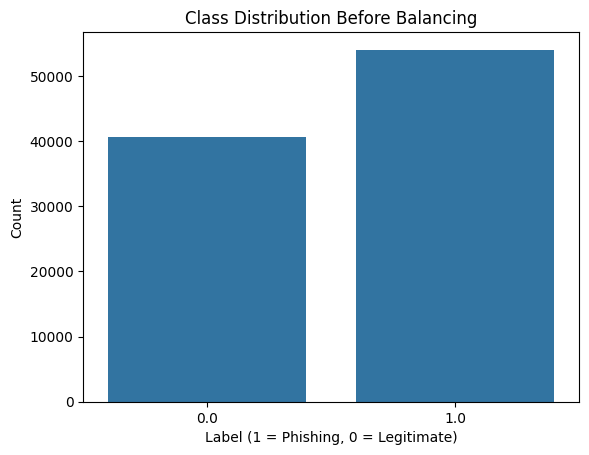

In [ ]:
sns.countplot(x='Label', data=df)
plt.title("Class Distribution Before Balancing")
plt.xlabel("Label (1 = Phishing, 0 = Legitimate)")
plt.ylabel("Count")
plt.show()

In [ ]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [ ]:
def extract_url_features(url):
    return {
        "URLLength": len(url),
        "DomainLength": len(urlparse(url).netloc),
        "HasAtSymbol": 1 if "@" in url else 0,
        "HasHyphen": 1 if "-" in url else 0,
        "HasHTTPS": 1 if url.startswith("https") else 0,
        "NumDots": url.count("."),
        "NumSlashes": url.count("/"),
        "HasIP": 1 if re.search(r"\d+\.\d+\.\d+\.\d+", url) else 0
    }
url_features = df['URL'].apply(lambda x: pd.Series(extract_url_features(x)))
df = pd.concat([df, url_features], axis=1)
print(df.head())

                                                 URL  Label  URLLength  \
0              http://www.crestonwood.com/router.php    0.0         37   
1  http://shadetreetechnology.com/V4/validation/a...    1.0         77   
2  https://support-appleld.com.secureupdate.duila...    1.0        126   
3                                 http://rgipt.ac.in    0.0         18   
4  http://www.iracing.com/tracks/gateway-motorspo...    0.0         55   

   DomainLength  HasAtSymbol  HasHyphen  HasHTTPS  NumDots  NumSlashes  HasIP  
0            19            0          0         0        3           3      0  
1            23            0          0         0        1           5      0  
2            50            0          1         1        4           5      0  
3            11            0          0         0        2           2      0  
4            15            0          1         0        2           5      0  


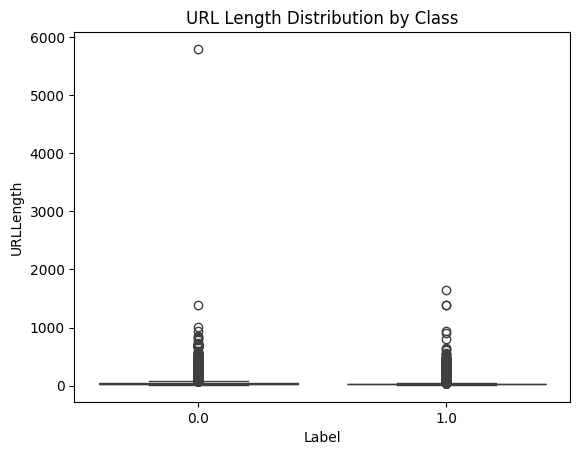

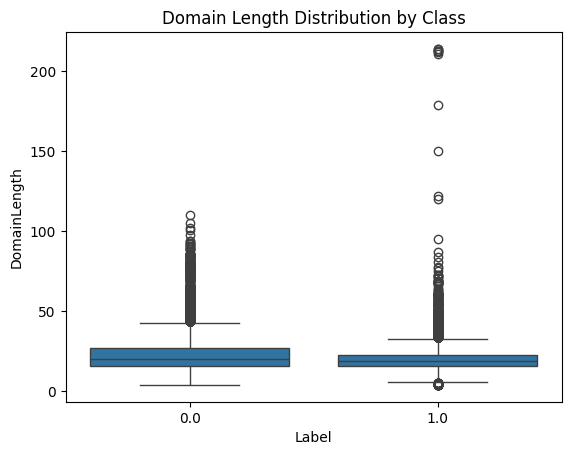

In [ ]:
sns.boxplot(x='Label', y='URLLength', data=df)
plt.title("URL Length Distribution by Class")
plt.show()
sns.boxplot(x='Label', y='DomainLength', data=df)
plt.title("Domain Length Distribution by Class")
plt.show()

In [ ]:
X = df.drop(columns=['URL', 'Label'])
y = df['Label']

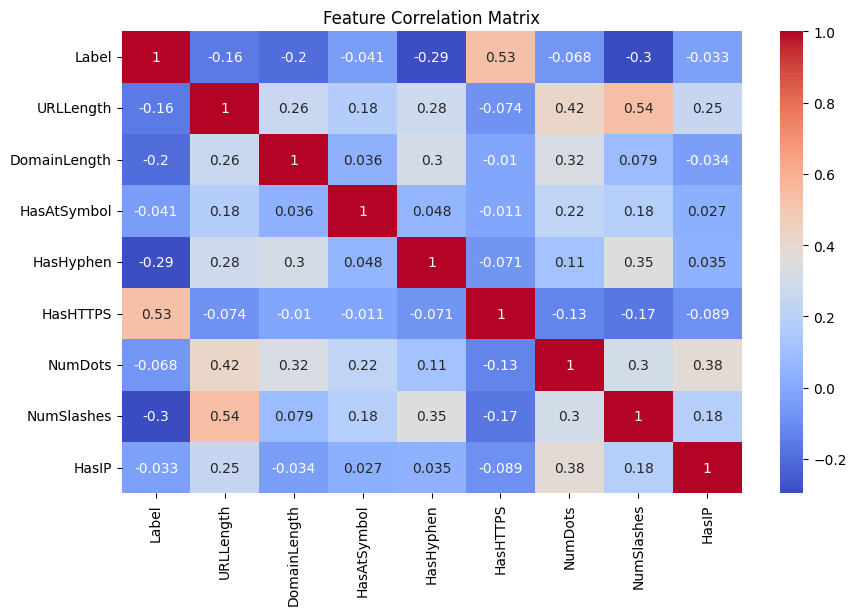

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['URL']).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print("After SMOTE:", y_resampled.value_counts())

After SMOTE: Label
0.0    54052
1.0    54052
Name: count, dtype: int64


In [ ]:
selector = SelectKBest(mutual_info_classif, k=6)
X_selected = selector.fit_transform(X_resampled, y_resampled)
selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['URLLength', 'DomainLength', 'HasHyphen', 'HasHTTPS', 'NumDots',
       'NumSlashes'],
      dtype='object')


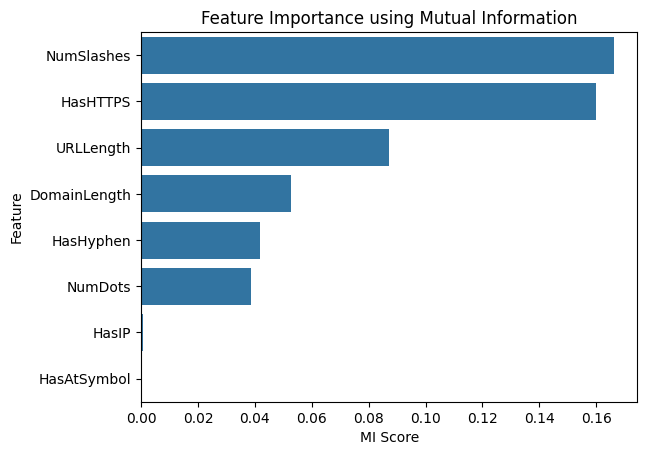

In [ ]:
mi_scores = mutual_info_classif(X_scaled, y)
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)
sns.barplot(x='MI Score', y='Feature', data=mi_df)
plt.title("Feature Importance using Mutual Information")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
print("RandomForest Accuracy:", accuracy_score(y_test, (rf_prob > 0.5).astype(int)))

RandomForest Accuracy: 0.9542574349012534


In [ ]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
print("XGBoost Accuracy:", accuracy_score(y_test, (xgb_prob > 0.5).astype(int)))

XGBoost Accuracy: 0.953656167614819


In [ ]:
final_prob = (rf_prob + xgb_prob) / 2
final_pred = (final_prob > 0.5).astype(int)

In [ ]:
print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1 Score:", f1_score(y_test, final_pred))
print("ROC-AUC:", roc_auc_score(y_test, final_pred))

Accuracy: 0.9543499375607049
Precision: 0.9745869166103005
Recall: 0.9330249768732655
F1 Score: 0.9533531830426769
ROC-AUC: 0.9543489512985327


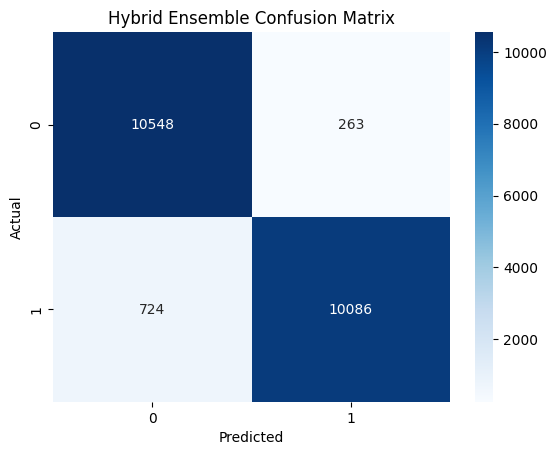

In [ ]:
cm = confusion_matrix(y_test, final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Hybrid Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

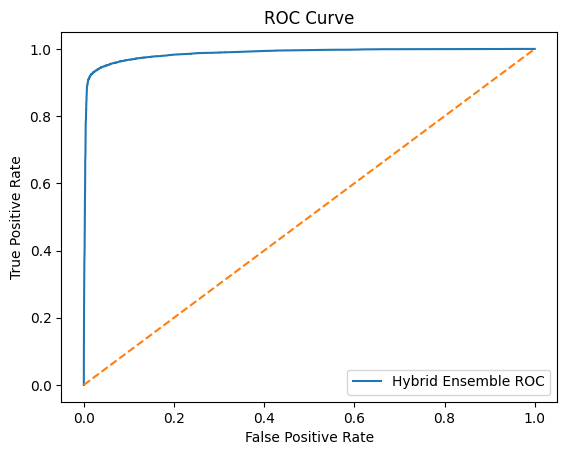

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, final_prob)
plt.plot(fpr, tpr, label="Hybrid Ensemble ROC")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()